## CAT DOG USING VGG

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path="cnn_dataset/training"
test_path="cnn_dataset/testing"

img_size=(224,224)
batch_size=32

train=ImageDataGenerator(rescale=1./255)
test=ImageDataGenerator(rescale=1./255)

train_data=train.flow_from_directory(train_path, target_size=img_size,batch_size=batch_size, class_mode='categorical')
test_data=test.flow_from_directory(test_path, target_size=img_size,batch_size=batch_size, class_mode='categorical')

Found 3794 images belonging to 2 classes.
Found 2024 images belonging to 2 classes.


In [2]:
#load vgg

from tensorflow.keras.applications import VGG19

base_model=VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

for l in base_model.layers:
    l.trainable=False

In [3]:
#adding custom layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model=Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [4]:
#training

history=model.fit(train_data, epochs=5, validation_data=test_data)

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 712s 6s/step - accuracy: 0.8376 - loss: 0.4412 - val_accuracy: 0.8888 - val_loss: 0.2723
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 700s 6s/step - accuracy: 0.9399 - loss: 0.1451 - val_accuracy: 0.8982 - val_loss: 0.2550
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 773s 7s/step - accuracy: 0.9768 - loss: 0.0718 - val_accuracy: 0.8918 - val_loss: 0.2879
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 787s 7s/step - accuracy: 0.9831 - loss: 0.0490 - val_accuracy: 0.8972 - val_loss: 0.2722
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 779s 7s/step - accuracy: 0.9926 - loss: 0.0310 - val_accuracy: 0.8987 - val_loss: 0.2988


In [5]:
#eval

loss, acc=model.evaluate(test_data)
print("acc:", acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 245s 4s/step - accuracy: 0.8987 - loss: 0.2988
acc: 0.8987154364585876


In [6]:
import numpy as np

x, y=next(test_data)
pred=model.predict(x)

print("pred:", np.argmax(pred[0]))
print("actual:", np.argmax(y[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
pred: 1
actual: 1


## CNN CMP

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(train_data.num_classes,activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn=cnn.fit(train_data, epochs=5, validation_data=test_data)

#eval
loss_cnn, acc_cnn=cnn.evaluate(test_data)
print("acc:", acc_cnn)

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 89s 738ms/step - accuracy: 0.5572 - loss: 2.7036 - val_accuracy: 0.5094 - val_loss: 0.6786
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 724ms/step - accuracy: 0.6247 - loss: 0.6283 - val_accuracy: 0.6512 - val_loss: 0.6140
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 722ms/step - accuracy: 0.7319 - loss: 0.5373 - val_accuracy: 0.6497 - val_loss: 0.6246
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 88s 742ms/step - accuracy: 0.8292 - loss: 0.4055 - val_accuracy: 0.7026 - val_loss: 0.6149
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 89s 747ms/step - accuracy: 0.9027 - loss: 0.2597 - val_accuracy: 0.6769 - val_loss: 0.7784
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.6769 - loss: 0.7784
acc: 0.676877498626709


In [8]:
ann = Sequential([
    Flatten(input_shape=(224,224,3)),
    Dense(128,activation='relu'),
    Dense(train_data.num_classes,activation='softmax')
])

ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_ann=ann.fit(train_data, epochs=5, validation_data=test_data)

#eval
loss_ann, acc_ann=ann.evaluate(test_data)
print("acc:", acc_ann)

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 37s 304ms/step - accuracy: 0.5303 - loss: 21.5431 - val_accuracy: 0.5548 - val_loss: 2.8568
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 260ms/step - accuracy: 0.5403 - loss: 7.7719 - val_accuracy: 0.5613 - val_loss: 2.5975
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 262ms/step - accuracy: 0.5538 - loss: 6.9509 - val_accuracy: 0.5870 - val_loss: 2.7523
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 36s 305ms/step - accuracy: 0.5944 - loss: 2.7208 - val_accuracy: 0.5667 - val_loss: 1.9305
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 39s 326ms/step - accuracy: 0.5880 - loss: 3.8643 - val_accuracy: 0.5795 - val_loss: 1.7583
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 130ms/step - accuracy: 0.5795 - loss: 1.7583
acc: 0.5795454382896423


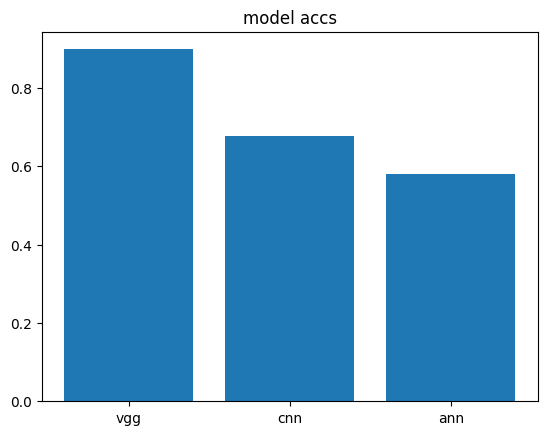

In [10]:
import matplotlib.pyplot as plt

vgg_acc=acc
models=["vgg", "cnn", "ann"]
scores=[vgg_acc, acc_cnn, acc_ann]
plt.bar(models, scores)
plt.title("model accs")
plt.show()